Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


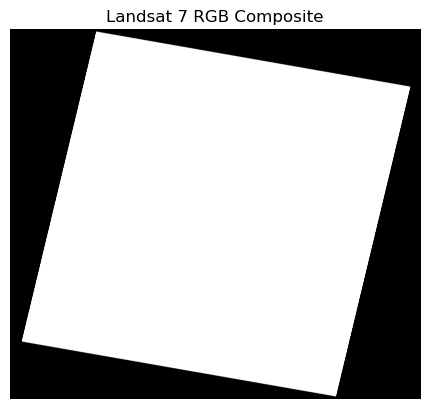

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load the RGB composite image
with rasterio.open("datasets2/images/2.tif") as src:
    # Read all three bands
    img_array = src.read()  # shape: (3, height, width)
    profile = src.profile  # optional: metadata like CRS, transform

# Convert to (height, width, 3) for image processing
img_array = np.transpose(img_array, (1, 2, 0))  # from (3, H, W) to (H, W, 3)

# Optional: Normalize to [0, 1] if needed for ML models
img_array = img_array.astype(np.float32)
img_array /= 255.0  # or use np.max(img_array) if values aren't in 0–255 range

# Preview
plt.imshow(img_array)
plt.title("Landsat 7 RGB Composite")
plt.axis('off')
plt.show()


In [2]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import glob
import os

# ---------- STEP 1: Load and resample all temporal images ----------

def load_and_resample(image_path, reference_shape, reference_transform, reference_crs):
    with rasterio.open(image_path) as src:
        data = src.read(
            out_shape=(
                src.count,
                reference_shape[0],
                reference_shape[1]
            ),
            resampling=Resampling.bilinear
        ).astype(np.float32)

        transform = src.transform
        scale_x = src.width / reference_shape[1]
        scale_y = src.height / reference_shape[0]

        new_transform = rasterio.Affine(
            transform.a / scale_x, transform.b, transform.c,
            transform.d, transform.e / scale_y, transform.f
        )

        return data / np.max(data), new_transform  # normalize to [0, 1]

# ---------- STEP 2: Create temporal stack ----------

def build_temporal_stack(image_paths):
    # Use the first image as reference
    with rasterio.open(image_paths[0]) as ref:
        ref_shape = ref.shape
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_data = ref.read().astype(np.float32)
        ref_data /= np.max(ref_data)

    temporal_stack = [ref_data]  # shape: (bands, height, width)
    
    for path in image_paths[1:]:
        data_resampled, _ = load_and_resample(path, ref_shape, ref_transform, ref_crs)
        temporal_stack.append(data_resampled)

    return np.stack(temporal_stack), ref_shape  # shape: (time, bands, H, W)

# ---------- STEP 3: Temporal interpolation (gap filling) ----------

def temporal_gap_fill(stack):
    # shape: (time, bands, H, W)
    filled = stack[0].copy()  # start with first date (reference)

    # Assume gaps are where pixel == 0
    mask = filled == 0

    # Loop over time dimension to fill gaps
    for t in range(1, stack.shape[0]):
        filled = np.where(mask, stack[t], filled)
        mask = filled == 0  # update mask (still missing)

    return filled  # shape: (bands, H, W)

# ---------- STEP 4: Run the pipeline ----------

# Get all image paths (sorted by time)
image_folder = "datasets/images"
image_paths = sorted(glob.glob(os.path.join(image_folder, "*.tif")))

stack, shape = build_temporal_stack(image_paths)
filled = temporal_gap_fill(stack)

# Convert to (H, W, 3) for model input
filled_image = np.transpose(filled, (1, 2, 0))

# Save output (optional)
def save_filled_image(output_path, filled_data, reference_path):
    with rasterio.open(reference_path) as ref:
        meta = ref.meta.copy()
        meta.update(dtype=rasterio.float32)
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(filled_data.astype(np.float32))

save_filled_image("filled_rgb_temporal.tif", filled, image_paths[0])
